In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

print("TensorFlow:", tf.__version__)

TensorFlow: 2.22.0-rc0


In [2]:
df = pd.read_csv("C:/python_projects/hack-292e04fe-neurohub/dataset_energy.csv")
df.head(5)

,ID,Статистическое время,Средняя скорость ветра(m/s),Нормализованная активная мощность,Средняя температура окружающей среды(°C)
0,1,2023-03-11 0:00:00,6.62,0.37,15.52
1,2,2023-03-11 0:10:00,6.70,0.39,15.38
2,3,2023-03-11 0:20:00,7.14,0.44,15.43
3,4,2023-03-11 0:30:00,7.82,0.50,15.41
4,5,2023-03-11 0:40:00,7.62,0.49,15.42


In [3]:
df["Статистическое время"] = pd.to_datetime(
    df["Статистическое время"]
)

df = df.sort_values(
    "Статистическое время"
)

df = df.set_index(
    "Статистическое время"
)


In [4]:
features = [
    "Средняя скорость ветра(m/s)",
    "Нормализованная активная мощность",
    "Средняя температура окружающей среды(°C)"
]

data = df[features].astype("float32").values

print("Размер данных:", data.shape)


Размер данных: (149499, 3)


In [5]:
train_size = int(len(data) * 0.8)

train_data = data[:train_size]
test_data = data[train_size:]

print("Train:", train_data.shape)
print("Test:", test_data.shape)


Train: (119599, 3)
Test: (29900, 3)


In [6]:
scaler = MinMaxScaler(
    feature_range=(0, 1)
)

train_scaled = scaler.fit_transform(
    train_data
)

test_scaled = scaler.transform(
    test_data
)


In [7]:
SEQ_LEN = 144

In [8]:
def create_sequences(
    data,
    seq_len,
    target_idx=1
):
    
    X = []
    y = []
    
    for i in range(seq_len, len(data)):
        
        X.append(
            data[i-seq_len:i]
        )
        
        y.append(
            data[i, target_idx]
        )
    
    return np.array(X), np.array(y)


In [9]:
X_train, y_train = create_sequences(
    train_scaled,
    SEQ_LEN,
    target_idx=1
)

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)


X_train: (119455, 144, 3)
y_train: (119455,)


In [10]:
test_input = np.concatenate([
    train_scaled[-SEQ_LEN:],
    test_scaled
])

X_test, y_test = create_sequences(
    test_input,
    SEQ_LEN,
    target_idx=1
)

print("X_test:", X_test.shape)
print("y_test:", y_test.shape)


X_test: (29900, 144, 3)
y_test: (29900,)


In [11]:
model = Sequential([
    
    LSTM(
        64,
        input_shape=(SEQ_LEN, 3),
        return_sequences=False
    ),
    
    Dropout(0.2),
    
    Dense(
        32,
        activation="relu"
    ),
    
    Dense(1)
])


c:\python_projects\hack-292e04fe-neurohub\env\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [12]:
model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        17,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,521 (76.25 KB)

 Trainable params: 19,521 (76.25 KB)

 Non-trainable params: 0 (0.00 B)

In [13]:
model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)


In [14]:
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=2,
    min_lr=1e-6,
    verbose=1
)


In [15]:
history = model.fit(
    X_train,
    y_train,
    
    epochs=30,
    
    batch_size=256,
    
    validation_split=0.1,
    
    callbacks=[
        early_stopping,
        reduce_lr
    ],
    
    verbose=1
)


Epoch 1/30
420/420 ━━━━━━━━━━━━━━━━━━━━ 39s 90ms/step - loss: 0.0142 - mae: 0.0755 - val_loss: 0.0076 - val_mae: 0.0557 - learning_rate: 0.0010
Epoch 2/30
420/420 ━━━━━━━━━━━━━━━━━━━━ 37s 89ms/step - loss: 0.0072 - mae: 0.0542 - val_loss: 0.0071 - val_mae: 0.0544 - learning_rate: 0.0010
Epoch 3/30
420/420 ━━━━━━━━━━━━━━━━━━━━ 37s 89ms/step - loss: 0.0067 - mae: 0.0518 - val_loss: 0.0080 - val_mae: 0.0593 - learning_rate: 0.0010
Epoch 4/30
420/420 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step - loss: 0.0066 - mae: 0.0503
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
420/420 ━━━━━━━━━━━━━━━━━━━━ 39s 92ms/step - loss: 0.0066 - mae: 0.0503 - val_loss: 0.0080 - val_mae: 0.0591 - learning_rate: 0.0010
Epoch 5/30
420/420 ━━━━━━━━━━━━━━━━━━━━ 38s 92ms/step - loss: 0.0063 - mae: 0.0489 - val_loss: 0.0079 - val_mae: 0.0586 - learning_rate: 5.0000e-04
Epoch 6/30
420/420 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step - loss: 0.0063 - mae: 0.0484
Epoch 6: ReduceLROnPlateau reducing learning ra

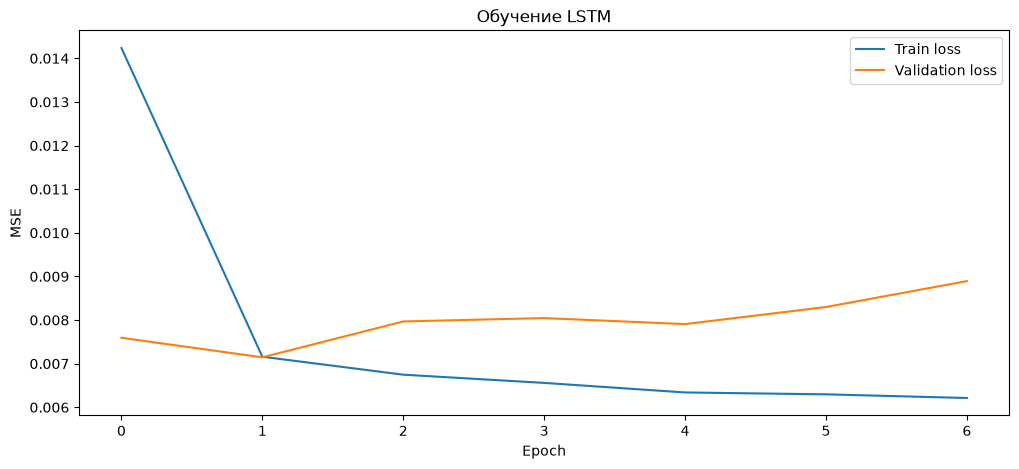

In [16]:
plt.figure(figsize=(12, 5))

plt.plot(
    history.history["loss"],
    label="Train loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation loss"
)

plt.title("Обучение LSTM")

plt.xlabel("Epoch")
plt.ylabel("MSE")

plt.legend()

plt.show()


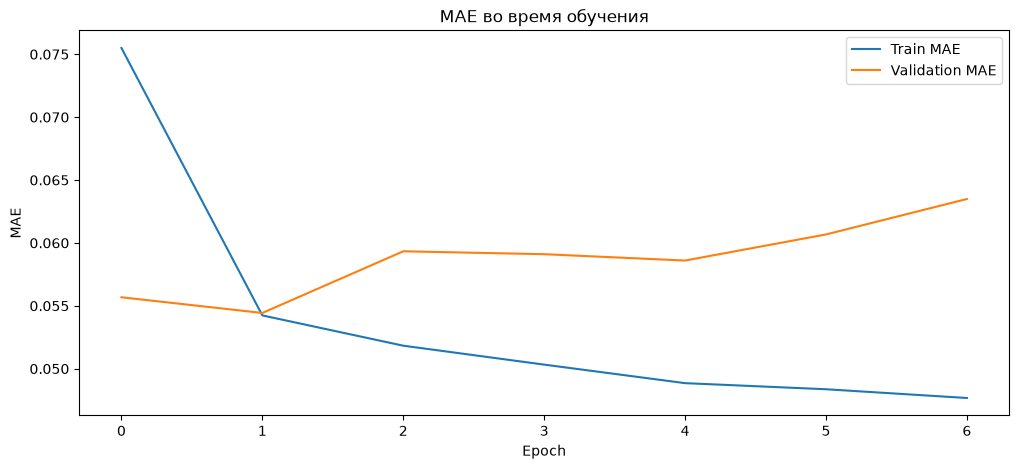

In [17]:
plt.figure(figsize=(12, 5))

plt.plot(
    history.history["mae"],
    label="Train MAE"
)

plt.plot(
    history.history["val_mae"],
    label="Validation MAE"
)

plt.title("MAE во время обучения")

plt.xlabel("Epoch")
plt.ylabel("MAE")

plt.legend()

plt.show()


In [18]:
pred_scaled = model.predict(
    X_test,
    batch_size=256
)


117/117 ━━━━━━━━━━━━━━━━━━━━ 4s 34ms/step


In [19]:
power_min = scaler.data_min_[1]
power_max = scaler.data_max_[1]

pred = (
    pred_scaled.flatten()
    * (power_max - power_min)
    + power_min
)

actual = (
    y_test
    * (power_max - power_min)
    + power_min
)


In [20]:
pred = np.clip(
    pred,
    0,
    1
)


In [21]:
mae_lstm = mean_absolute_error(
    actual,
    pred
)

print(
    f"LSTM MAE: {mae_lstm:.6f}"
)


LSTM MAE: 0.047301


In [22]:
rmse_lstm = np.sqrt(
    mean_squared_error(
        actual,
        pred
    )
)

print(
    f"LSTM RMSE: {rmse_lstm:.6f}"
)


LSTM RMSE: 0.077670


In [23]:
lstm_results = pd.DataFrame({
    "actual": actual,
    "prediction": pred
})

lstm_results["error"] = (
    lstm_results["actual"]
    - lstm_results["prediction"]
)

lstm_results.head()


,actual,prediction,error
0,0.44,0.404097,0.035903
1,0.40,0.407759,-0.007759
2,0.40,0.373869,0.026131
3,0.39,0.375026,0.014973
4,0.22,0.358443,-0.138443


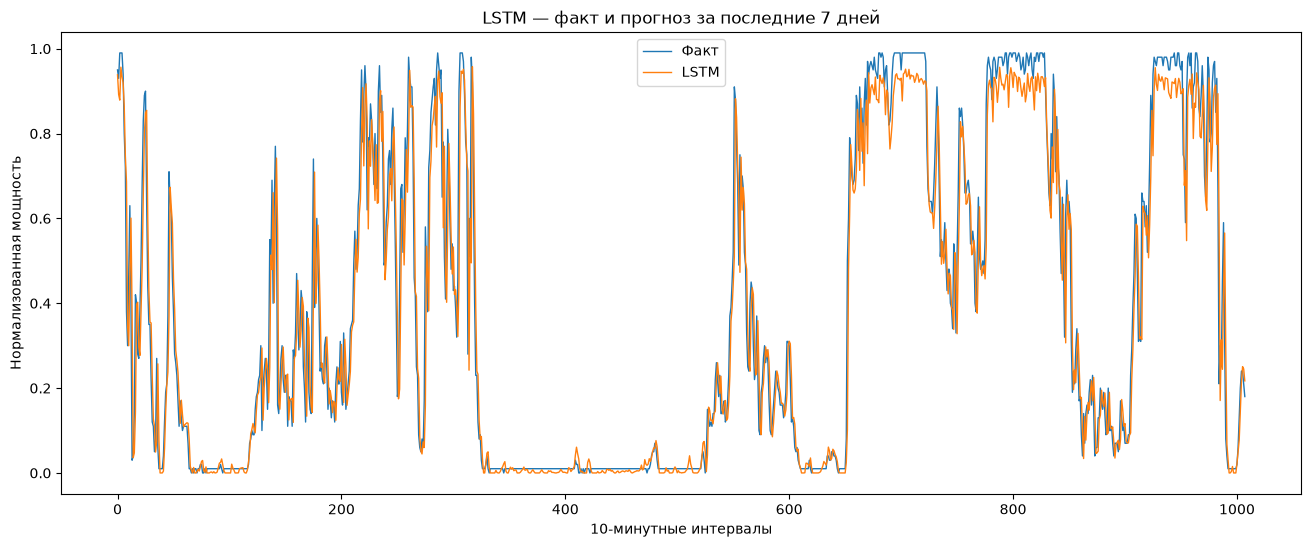

In [24]:
n = 144 * 7

plt.figure(figsize=(16, 6))

plt.plot(
    actual[-n:],
    label="Факт",
    linewidth=1
)

plt.plot(
    pred[-n:],
    label="LSTM",
    linewidth=1
)

plt.title(
    "LSTM — факт и прогноз за последние 7 дней"
)

plt.xlabel(
    "10-минутные интервалы"
)

plt.ylabel(
    "Нормализованная мощность"
)

plt.legend()

plt.show()


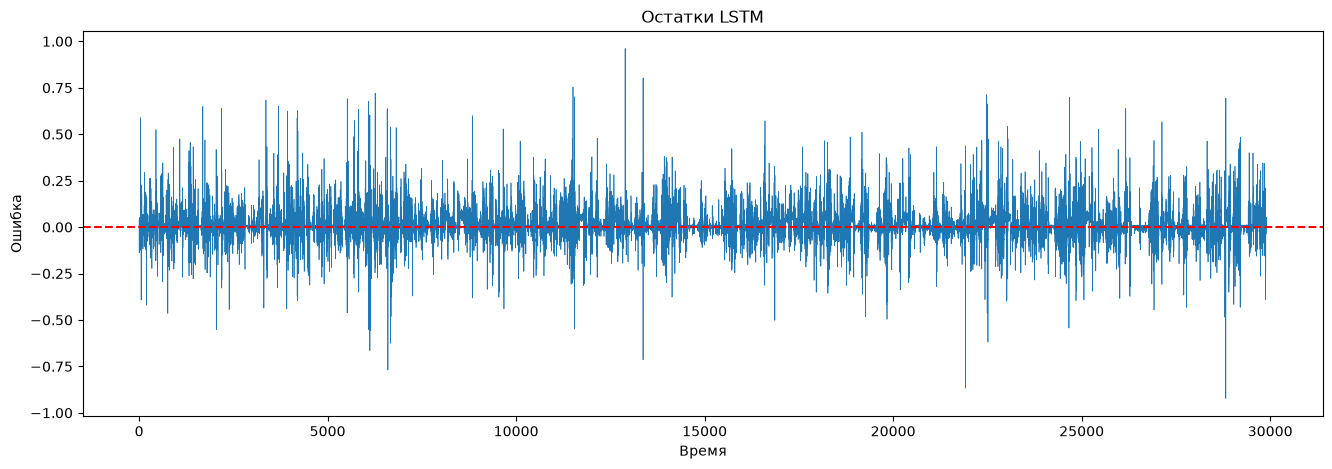

In [25]:
residuals = actual - pred

plt.figure(figsize=(16, 5))

plt.plot(
    residuals,
    linewidth=0.5
)

plt.axhline(
    0,
    color="red",
    linestyle="--"
)

plt.title("Остатки LSTM")

plt.xlabel("Время")
plt.ylabel("Ошибка")

plt.show()


In [26]:
model.save(
    "model_artifacts/lstm_wind_power.keras"
)


In [27]:
lstm_results.to_csv(
    "model_artifacts/lstm_predictions.csv",
    index=False
)


In [28]:
comparison = pd.DataFrame({
    "Model": [
        "LSTM"
    ],
    "MAE": [
        mae_lstm
    ],
    
    "RMSE": [
        rmse_lstm
    ]
})

comparison


,Model,MAE,RMSE
0,LSTM,0.047301,0.07767
